In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("final.csv")


# 1. DATA STRUCTURE VALIDATION

print("=== Dataset Info ===")
df.info()


# 2. MISSING VALUES CHECK

print("\n=== Missing Values ===")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values detected in the dataset.")
else:
    print("\nMissing values detected.")


# 3. DUPLICATE RECORDS CHECK

duplicates = df.duplicated().sum()

print("\n=== Duplicate Rows ===")
print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Month                 150000 non-null  int64  
 1   WeekOfMonth           150000 non-null  int64  
 2   DayOfWeek             150000 non-null  int64  
 3   Make                  150000 non-null  object 
 4   AccidentArea          150000 non-null  object 
 5   DayOfWeekClaimed      150000 non-null  int64  
 6   MonthClaimed          150000 non-null  int64  
 7   WeekOfMonthClaimed    150000 non-null  int64  
 8   Sex                   150000 non-null  object 
 9   MaritalStatus         150000 non-null  object 
 10  Age                   150000 non-null  int64  
 11  Fault                 150000 non-null  object 
 12  PolicyType            150000 non-null  object 
 13  VehicleCategory       150000 non-null  object 
 14  VehiclePrice          150000 no

In [ ]:
import pandas as pd

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

X = df[['VehiclePrice', 'Deductible']].values

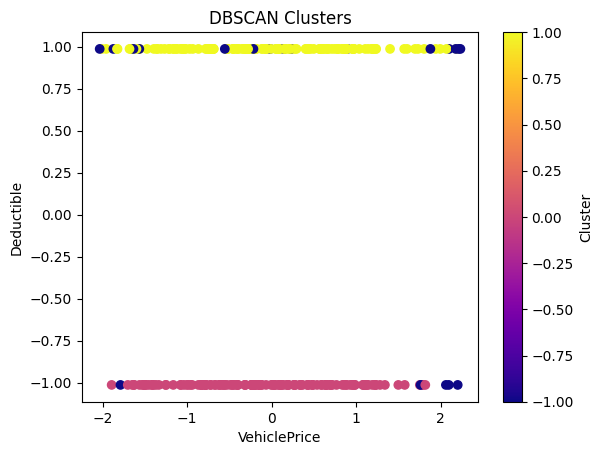

Unique clusters: [-1  0  1]
Noise points (-1): 20
Cluster Distribution:
Cluster 0: 37946
Cluster 1: 74809
Cluster 2: 37245


In [ ]:
# DBSCAN Clustering
# Sample the data first
df_sample = df.sample(n=300, random_state=42)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[['VehiclePrice', 'Deductible', 'Age']])

# Apply DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Plot
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_dbscan, cmap='plasma')
plt.title('DBSCAN Clusters')
plt.xlabel('VehiclePrice')
plt.ylabel('Deductible')
plt.colorbar(label='Cluster')
plt.show()

# Print cluster info
import numpy as np
print("Unique clusters:", np.unique(y_dbscan))
print("Noise points (-1):", np.sum(y_dbscan == -1))
# Count number of points in each cluster
import numpy as np
unique, counts = np.unique(y_kmeans, return_counts=True)
print("Cluster Distribution:")
for i in range(len(unique)):
    print(f"Cluster {unique[i]}:", counts[i])

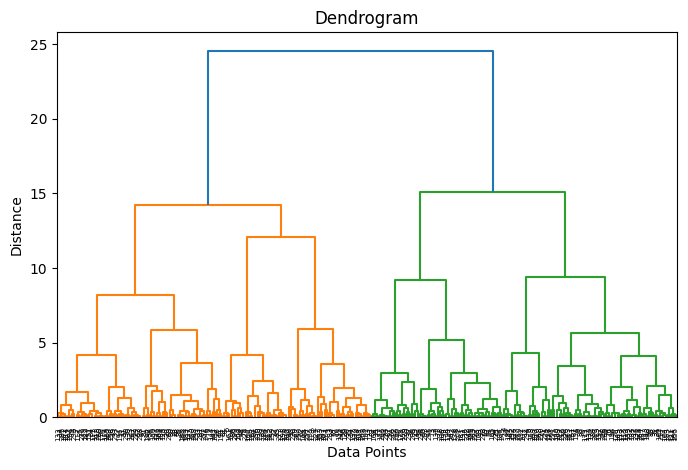

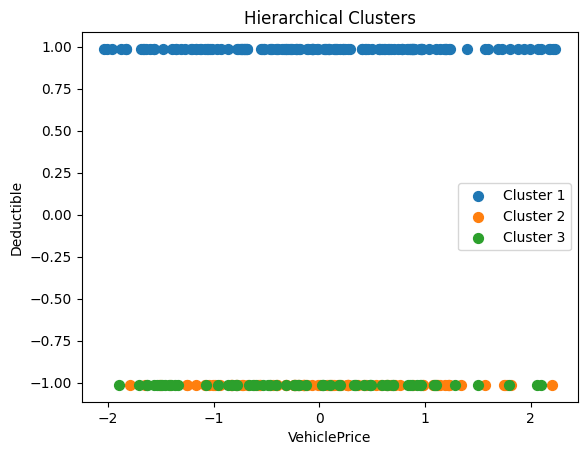

Cluster Distribution:
Cluster 0: 37946
Cluster 1: 74809
Cluster 2: 37245


In [ ]:
# HIERARCHICAL CLUSTERING
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("final.csv")

# Cleaning
df = df.drop_duplicates()
df = df.dropna(subset=['VehiclePrice', 'Deductible', 'Age'])

# Take small sample for dendrogram
df_sample = df[['VehiclePrice', 'Deductible', 'Age']].sample(
    n=300, random_state=42
)

# Scaling
scaler = StandardScaler()
X_sample = scaler.fit_transform(df_sample)

# Dendrogram
plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Apply model on same sample
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_hc = hc.fit_predict(X_sample)

# Visualization
plt.scatter(X_sample[y_hc == 0, 0], X_sample[y_hc == 0, 1], s=50, label='Cluster 1')
plt.scatter(X_sample[y_hc == 1, 0], X_sample[y_hc == 1, 1], s=50, label='Cluster 2')
plt.scatter(X_sample[y_hc == 2, 0], X_sample[y_hc == 2, 1], s=50, label='Cluster 3')
plt.title('Hierarchical Clusters')
plt.xlabel('VehiclePrice')
plt.ylabel('Deductible')
plt.legend()
plt.show()

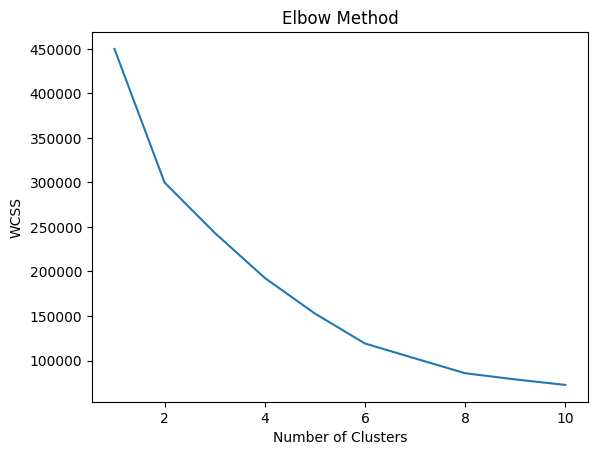

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


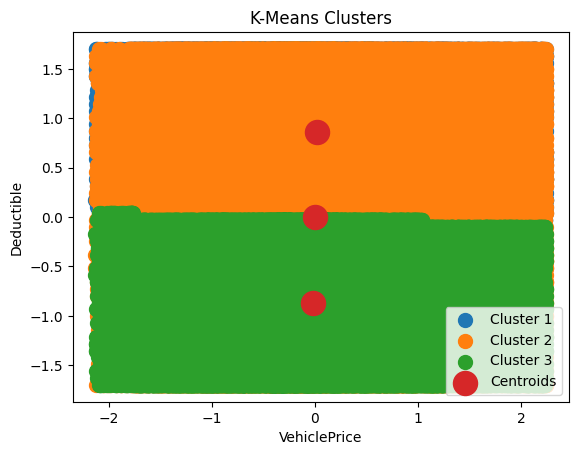

Cluster Distribution:
Cluster 0: 37946
Cluster 1: 74809
Cluster 2: 37245


In [ ]:
# K-MEANS CLUSTERING

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("final.csv")


# Select features

X = df[['VehiclePrice', 'Age', 'Deductible']].values

#  IMPORTANT FIX: Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 1: Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot elbow graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Step 2: Apply K-Means

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Visualization
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, label='Cluster 3')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, label='Centroids')

plt.title('K-Means Clusters')
plt.xlabel('VehiclePrice')
plt.ylabel('Deductible')
plt.legend()
plt.show()



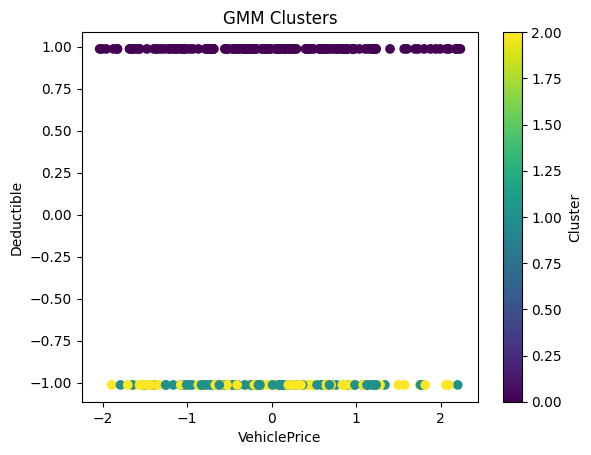

Cluster Distribution:
Cluster 0: 37946
Cluster 1: 74809
Cluster 2: 37245


In [ ]:
# GAUSSIAN MIXTURE MODEL (GMM)
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load and sample dataset
df = pd.read_csv("final.csv")
df_sample = df.sample(n=300, random_state=42)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(df_sample[['VehiclePrice', 'Deductible', 'Age']])

# Apply GMM
gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X)

# Visualization
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis')
plt.title('GMM Clusters')
plt.xlabel('VehiclePrice')
plt.ylabel('Deductible')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Count number of points in each cluster
import numpy as np
unique, counts = np.unique(y_kmeans, return_counts=True)
print("Cluster Distribution:")
for i in range(len(unique)):
    print(f"Cluster {unique[i]}:", counts[i])

Cluster Distribution:
Cluster 0: 37946
Cluster 1: 74809
Cluster 2: 37245
